# Entorno de Análisis Local (Fase 2)

Acá ya no dependemos de aceleradores gráficos. Levantamos el `.csv` de Colab y usamos matemática pura para limpiar los datos y llevarlos a coordenadas de la cancha.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.calibration.homography import CourtCalibrator
from src.features.smoothing import TrajectorySmoother


In [3]:
# 1. Cargamos la salida cruda de YOLO
df = pd.read_csv('../data/processed/tracking_pass_and_cut_raw.csv')
print(f"Frames analizados: {df['frame'].nunique()}")
df.head()

Frames analizados: 659


,frame,track_id,class_id,x1,y1,x2,y2,confidence
0,0,1,0,297.13,489.88,479.03,894.97,0.878
1,0,2,0,536.84,380.45,647.42,680.98,0.830
2,0,3,0,1466.68,436.24,1567.90,731.89,0.790
3,0,4,0,928.98,356.44,997.88,577.04,0.746
4,0,5,0,1277.97,373.00,1344.15,542.23,0.694


### Definición de Puntos para Homografía
Normalmente estos puntos se extraen haciendo click sobre un frame estático del video. 
Acá los simulamos: Puntos `src` son píxeles del video. Puntos `dst` son metros en cancha FIBA (Ej: 28m x 15m).

In [4]:
# reemplazar src_pts por píxeles reales de tu video
src_pts = np.array([
    [678, 544],  # Esquina inferior izquierda pintura
    [233, 618], # Esquina inferior derecha pintura
    [1188, 598],  # Esquina superior tiro libre izq
    [805, 706]  # Esquina superior tiro libre der
], dtype=np.float32)

dst_pts = np.array([                                                                                                                                                                                                                 
    [0.0, 5.18],  # Metro: Línea de fondo izq                                                                                                                                                                                        
    [0.0, 10.05], # Metro: Línea de fondo der                                                                                                                                                                                        
    [5.79, 5.18], # Metro: Tiro libre izq                                                                                                                                                                                            
    [5.79, 10.05] # Metro: Tiro libre der                                                                                                                                                                                            
], dtype=np.float32) 

calibrator = CourtCalibrator()
calibrator.calculate_homography(src_pts, dst_pts)

# Proyectamos al plano de la cancha
df_court = calibrator.apply_to_dataframe(df)
df_court.head()

,frame,track_id,class_id,x1,y1,x2,y2,confidence,x_base_px,y_base_px,x_court_m,y_court_m
0,0,1,0,297.13,489.88,479.03,894.97,0.878,388.08,894.97,6.742333,13.992551
1,0,2,0,536.84,380.45,647.42,680.98,0.830,592.13,680.98,4.091580,10.230273
2,0,3,0,1466.68,436.24,1567.90,731.89,0.790,1517.29,731.89,9.892273,8.281592
3,0,4,0,928.98,356.44,997.88,577.04,0.746,963.43,577.04,3.558669,5.309154
4,0,5,0,1277.97,373.00,1344.15,542.23,0.694,1311.06,542.23,5.160844,1.623204


In [6]:
# 2. Limpieza de Ruido (Savitzky-Golay)
smoother = TrajectorySmoother(window_length=15)
df_clean = smoother.smooth_dataframe(df_court)

# Guardamos el CSV final pulido para dárselo a Gemini en la Fase 3
df_clean.to_csv('../data/processed/tracking_cleaned.csv', index=False)
print("Datos espaciales guardados.")
df_clean.head()

Datos espaciales guardados.


,frame,track_id,class_id,x1,y1,x2,y2,confidence,x_base_px,y_base_px,x_court_m,y_court_m,x_court_m_smooth,y_court_m_smooth
0,0,1,0,297.13,489.88,479.03,894.97,0.878,388.080,894.97,6.742333,13.992551,6.731557,13.985605
8,1,1,0,304.57,493.09,482.71,889.96,0.898,393.640,889.96,6.703537,13.931405,6.735647,13.953108
15,2,1,0,311.18,503.19,485.65,892.14,0.890,398.415,892.14,6.747738,13.941092,6.737597,13.926365
21,3,1,0,318.68,510.11,489.06,889.64,0.893,403.870,889.64,6.738580,13.903988,6.737966,13.904928
27,4,1,0,323.28,513.60,492.42,889.88,0.883,407.850,889.88,6.756580,13.896856,6.737310,13.888350


### Visualización de Trayectorias (Radar Top-View)

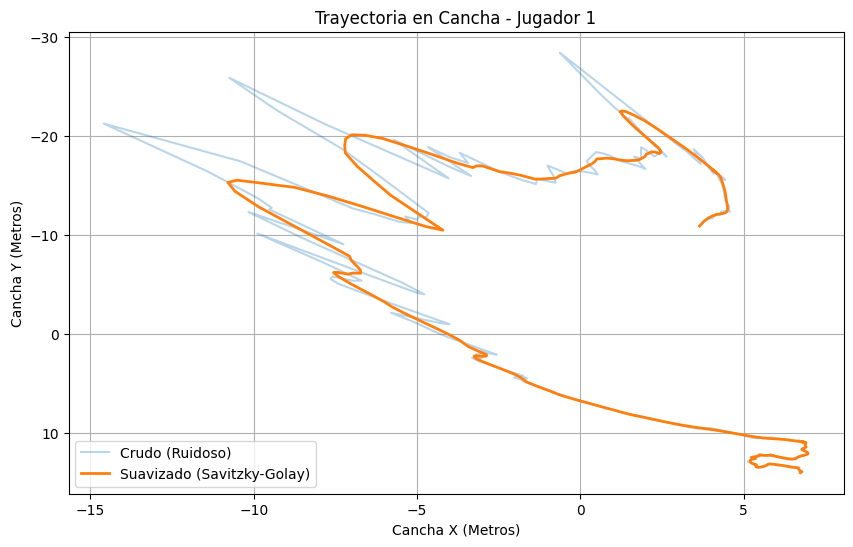

In [7]:
plt.figure(figsize=(10, 6))

# Dibujamos la trayectoria del jugador más activo (o el que quieras)
player_id = df_clean['track_id'].value_counts().idxmax()
player_data = df_clean[df_clean['track_id'] == player_id]

plt.plot(player_data['x_court_m'], player_data['y_court_m'], label='Crudo (Ruidoso)', alpha=0.3)
plt.plot(player_data['x_court_m_smooth'], player_data['y_court_m_smooth'], label='Suavizado (Savitzky-Golay)', linewidth=2)

plt.title(f'Trayectoria en Cancha - Jugador {player_id}')
plt.xlabel('Cancha X (Metros)')
plt.ylabel('Cancha Y (Metros)')
plt.legend()
plt.grid(True)
plt.gca().invert_yaxis() # Depende de cómo orientes los ejes de tu cancha
plt.show()

In [8]:
# 1. Instalamos la SDK de Google (Corré esto una sola vez)                                                                                            
!pip install google-genai 


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [12]:
import sys
import os
# Le decimos a Python que mire una carpeta hacia atrás (la raíz del proyecto)
sys.path.append(os.path.abspath('..'))


# 2. Importamos los módulos de la Fase 3 que acabamos de armar                                                                                        
from src.features.tactical_features import TacticalFeatureExtractor                                                                                   
from src.analytics.gemini_engine import GeminiTacticalEngine                                                                                          
                                                                                                                                                          
# 3. Ingeniería de Datos                                                                                                                              
extractor = TacticalFeatureExtractor(fps=30)                                                                                                          
df_features = extractor.calculate_features(df_clean)                                                                                                  
                                                                                                                                                          
# ---> RECORTADOR DE BLOQUE <---
# Filtramos para que SOLO agarre desde el inicio hasta el frame 150 (5 segundos a 30 FPS)
# Así nos aseguramos de no enviarle toda la "basura" irrelevante del video

df_bloque_clave = df_features[df_features['frame'] < 150]
# df_jugada_aislada = df_features[
#     (df_features['frame'] >= 150) & 
#     (df_features['frame'] <= 360)  # Cortamos antes de que explote la cámara
# ]

  
# Generamos el JSON con los datos re-comprimidos 

# –---------------------------
json_payload = extractor.to_gemini_json(df_bloque_clave) # REEMPLAZAR por el dataframe extraido de df_features
# –---------------------------

print(f"Tamaño del payload recortado: {len(json_payload)} caracteres.")
  
# 4. Llamada al Motor de Gemini

engine = GeminiTacticalEngine(api_key=None)
  
print("El Entrenador Gemini está analizando el bloque...")
resultado = engine.analyze_play(json_payload)
  
print("\n" + "="*50)
print("🏀 SCOUTING REPORT: PASAR Y CORTAR")
print("="*50)
print(f"Pase ejecutado (Eje a 45°): {'Sí' if resultado.is_pass_executed else 'No'}")
print(f"Corte hacia el centro   : {'Sí' if resultado.is_cut_executed else 'No'}")
print(f"Intensidad del Corte    : {resultado.cut_speed_classification}")
print(f"Toma de decisión (Final): {resultado.cut_destination}")
print(f"\n🧠 Explicación del Analista:\n{resultado.technical_explanation}")

Tamaño del payload recortado: 18840 caracteres.
El Entrenador Gemini está analizando el bloque...

🏀 SCOUTING REPORT: PASAR Y CORTAR
Pase ejecutado (Eje a 45°): No
Corte hacia el centro   : No
Intensidad del Corte    : No hubo corte
Toma de decisión (Final): No aplica

🧠 Explicación del Analista:
No se registra la presencia del balón (class_id=32) en la matriz de datos cinemáticos provista. Sin la trayectoria del balón no se puede verificar la ejecución de un pase desde el eje central hacia las alas, por lo que no se cumple la condición inicial de la acción de pasar y cortar.
